<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/00_AED_inicial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB00 — Análise Exploratória dos Dados Brutos BORG/Kaggle

## 1. Contexto

Este notebook realiza a Análise Exploratória de Dados (AED) exclusivamente sobre o dataset bruto BORG/Kaggle, representado pelo arquivo `borg_traces_data.csv`.

A análise é feita diretamente a partir da fonte primária, sem utilização de artefatos produzidos pelos notebooks NB01 a NB09. Essa separação é uma decisão metodológica importante: antes de aplicar limpeza, agregação temporal, rotulagem, engenharia de atributos ou modelagem, é necessário compreender a estrutura original dos dados.

Dessa forma, o NB00 cumpre o papel de caracterizar o dado bruto que alimenta o pipeline experimental, enquanto a AED dos artefatos processados é realizada posteriormente no NB07, a partir dos achados dos notebooks NB01 a NB06.

## 2. Objetivo

O objetivo deste notebook é caracterizar o dataset bruto antes de qualquer transformação analítica do pipeline.

Especificamente, este notebook busca:

1. Ler diretamente o arquivo `borg_traces_data.csv` a partir da área de dados brutos;
2. Caracterizar a estrutura geral do dataset, incluindo número de registros, número de colunas, tipos de dados e valores ausentes;
3. Descrever a distribuição dos principais campos operacionais, especialmente `event`, `failed`, `scheduling_class` e `priority`;
4. Avaliar a cobertura temporal da série bruta com base na variável `time`;
5. Identificar o comportamento singular do bloco inicial da série, especialmente os registros concentrados em `time == 0` ou na primeira hora relativa;
6. Verificar a cardinalidade de identificadores operacionais, como `machine_id`, `collection_id` e `instance_index`;
7. Avaliar a presença de atributos de recurso, como `resource_request`, `average_usage`, `maximum_usage`, `assigned_memory` e variáveis correlatas;
8. Construir uma série exploratória em janelas de 5 minutos diretamente a partir do dado bruto;
9. Realizar uma análise exploratória de sensibilidade sobre o impacto do bloco inicial;
10. Gerar artefatos descritivos próprios do NB00, incluindo figuras, resumos JSON e uma série exploratória auxiliar.

## 3. Papel no Pipeline

O NB00 é um notebook descritivo e independente.

Ele não executa o pipeline oficial de preparação, agregação, rotulagem ou modelagem. Sua função é documentar as propriedades da fonte primária e fornecer evidências iniciais para decisões tomadas nos notebooks seguintes.

Em particular, o NB00 apoia:

1. A justificativa para seleção e tratamento de colunas no NB01;
2. A interpretação do bloco inicial atípico documentado posteriormente no pipeline;
3. A compreensão preliminar da distribuição de eventos e falhas;
4. A contextualização da agregação temporal em janelas de 5 minutos;
5. A distinção entre análise do dado bruto e análise dos artefatos processados.

## 4. Artefatos Utilizados

Este notebook utiliza como entrada primária apenas:

- `borg_traces_data.csv`: dataset bruto BORG/Kaggle, localizado na área de dados brutos.

O arquivo `00_aed_source_cache.parquet` é um cache técnico interno, gerado pelo próprio NB00 a partir do CSV bruto, com a finalidade de permitir agregações com DuckDB de forma mais eficiente e com menor consumo de memória.

Como regra de reprodutibilidade, esse cache é sempre recriado durante a execução da célula consolidada do NB00:

1. se o cache já existir, ele será removido e criado novamente;
2. se o cache não existir, ele será criado normalmente a partir do CSV bruto.

Nenhum artefato produzido pelos notebooks NB01 a NB09 é utilizado neste notebook.

## 5. Estrutura do Notebook

O notebook está organizado em uma única célula consolidada de código, dividida internamente em blocos numerados.

A célula consolidada realiza:

1. Montagem do Google Drive e configuração do repositório;
2. Leitura direta de `borg_traces_data.csv`;
3. Remoção da coluna auxiliar `Unnamed: 0`, quando presente;
4. Análise de dimensões, tipos de dados e valores ausentes;
5. Análise de `event`, `failed`, `scheduling_class` e `priority`;
6. Tratamento exploratório local da variável `time`;
7. Identificação do bloco inicial da série;
8. Análise de cardinalidade de identificadores;
9. Avaliação da presença de atributos de recurso;
10. Verificação de consistência semântica entre `event == "FAIL"` e `failed == 1`;
11. Geração das figuras e do resumo `00_aed_raw_summary.json`;
12. Recriação do cache técnico `00_aed_source_cache.parquet` a partir do CSV bruto;
13. Leitura analítica do cache com DuckDB;
14. Construção de uma série exploratória em janelas de 5 minutos;
15. Cálculo exploratório de taxa de falha por janela;
16. Análise descritiva da distribuição temporal;
17. Análise exploratória do bloco inicial;
18. Análise de sensibilidade com e sem a primeira hora;
19. Geração do resumo consolidado `00_aed_summary.json`;
20. Persistência da série exploratória auxiliar em formatos Parquet e CSV.

Embora o código esteja em uma única célula, os blocos internos preservam a separação lógica entre a AED estrutural do CSV bruto e a AED temporal/agregada baseada no cache técnico recriado pelo próprio NB00.

## 6. Observações Metodológicas

Este notebook possui caráter estritamente exploratório.

As variáveis `hour`, `bucket_id` e demais derivações temporais aqui produzidas são usadas apenas para AED do dado bruto. Elas não substituem as transformações oficiais do pipeline.

O limiar `μ + 2σ` calculado neste notebook é apenas uma referência exploratória inicial. O limiar oficial de criticidade, quando aplicável ao pipeline experimental, deve ser tratado nos notebooks posteriores.

A série exploratória de 5 minutos gerada no NB00 não é consumida pelos notebooks seguintes. Ela serve apenas para compreender se a estrutura temporal do dado bruto é compatível com a estratégia de discretização adotada no projeto.

## 7. Fronteira entre NB00 e NB07

A separação entre NB00 e NB07 deve ser mantida da seguinte forma:

- O NB00 responde: **“Como é o dataset bruto BORG/Kaggle antes do pipeline?”**
- O NB07 responde: **“O que os notebooks NB01 a NB06 produziram e quais achados exploratórios emergem dos artefatos já processados?”**

Assim, o NB00 caracteriza a fonte primária, enquanto o NB07 consolida a AED dos dados já preparados, agregados, tratados e rotulados pelo pipeline.

Mounted at /content/drive
REPO_DIR: /content/drive/MyDrive/Mestrado/PPCOMP_DM
RAW_PATH: /content/drive/MyDrive/Mestrado/02-datasets/01-raw
REPORTS_PATH: /content/drive/MyDrive/Mestrado/04-reports
CSV_FILE: /content/drive/MyDrive/Mestrado/02-datasets/01-raw/borg_traces_data.csv
FIG_DIR_RAW: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed_raw
FIG_DIR_AED: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed
[NB00_AED] Arquivo encontrado: /content/drive/MyDrive/Mestrado/02-datasets/01-raw/borg_traces_data.csv
[NB00_AED] Tamanho do arquivo: 313.1 MB
[NB00_AED] Leitura OK: 405894 linhas x 33 colunas
[NB00_AED] Colunas: ['time', 'instance_events_type', 'collection_id', 'scheduling_class', 'collection_type', 'priority', 'alloc_collection_id', 'instance_index', 'machine_id', 'resource_request', 'constraint', 'collections_events_type', 'user', 'collection_name', 'collection_logical_name', 'start_after_collection_ids', 'vertical_scaling', 'scheduler', 'start_time', 'end_time',

,dtype
time,int64
instance_events_type,int64
collection_id,int64
scheduling_class,int64
collection_type,int64
priority,int64
alloc_collection_id,int64
instance_index,int64
machine_id,int64
resource_request,object



Colunas com valores ausentes:


,missing_count,missing_pct
memory_accesses_per_instruction,124688,30.72
cycles_per_instruction,124688,30.72
scheduler,959,0.24
vertical_scaling,959,0.24
resource_request,774,0.19


[NB00_AED] Registros com time > sentinela (10000000000000000): 3 → convertidos para NaN
[NB00_AED] Total time NaN após tratamento temporal local: 3

===== COBERTURA TEMPORAL =====
time min: 0
time max: 2678923967375
Duração aproximada: 744.1 horas
Janelas de 5 min estimadas: 8930

Volume mínimo por hora: 26
Volume máximo por hora: 56740
Volume médio por hora : 544.8


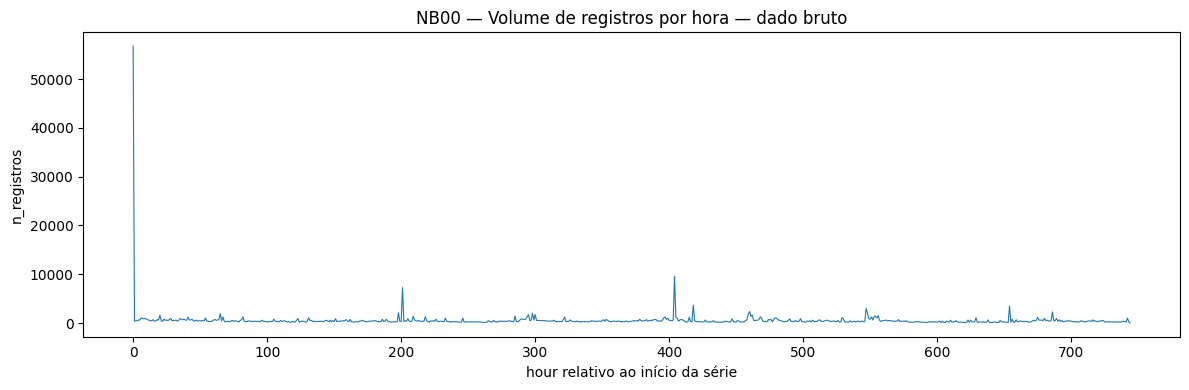

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed_raw/fig_01_volume_por_hora.png
[NB00_AED] Registros em hour == 0: 56740 (14.0% do total com time válido)

[Distribuição de event em hour == 0]


,count
event,
FAIL,37150
ENABLE,18682
FINISH,666
SCHEDULE,161
LOST,78
KILL,3


[NB00_AED] Registros failed == 1 em hour == 0: 37150


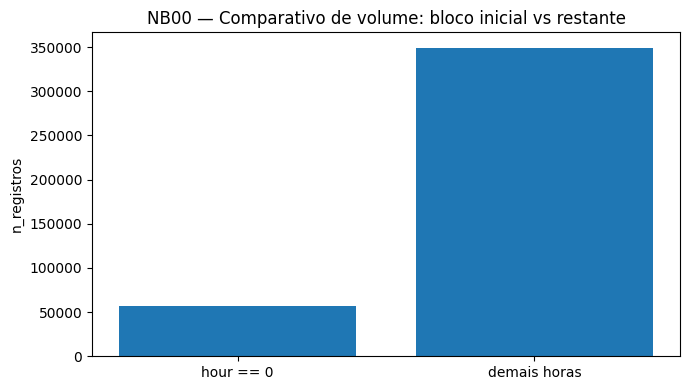

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed_raw/fig_02_volume_hour0_vs_outros.png

===== DISTRIBUIÇÃO DE EVENTOS =====


,count,pct
event,,
FINISH,92867,22.879619
FAIL,92678,22.833055
ENABLE,75907,18.701188
SCHEDULE,69104,17.025135
LOST,59515,14.662695
EVICT,14756,3.635432
KILL,951,0.234298
UPDATE_PENDING,111,0.027347
QUEUE,4,0.000985


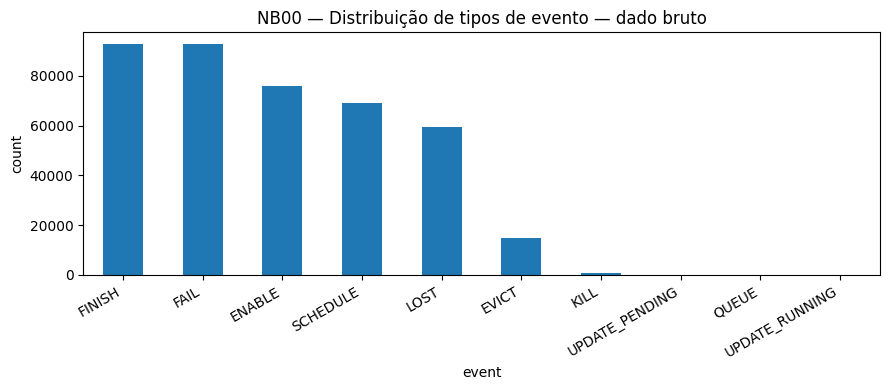

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed_raw/fig_03_event_distribution.png

===== DISTRIBUIÇÃO DE FAILED =====


,count
failed_num,
0,313216
1,92678


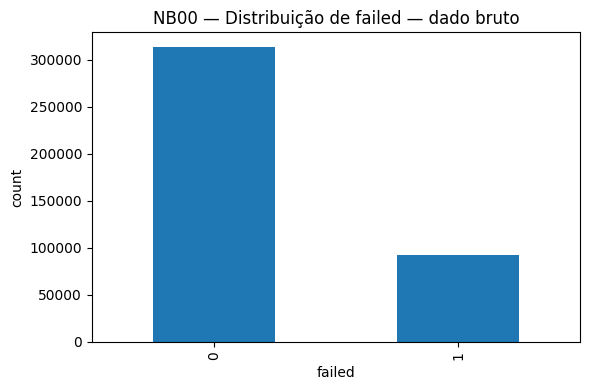

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed_raw/fig_04_failed_distribution.png
[NB00_AED] Registros failed == 1: 92678 (22.8%)
[NB00_AED] Concordância event == 'FAIL' vs failed == 1: 1.0000

===== SCHEDULING CLASS =====


,count,pct
scheduling_class,,
0,120414,29.666366
1,105329,25.949879
2,131567,32.414128
3,48584,11.969628


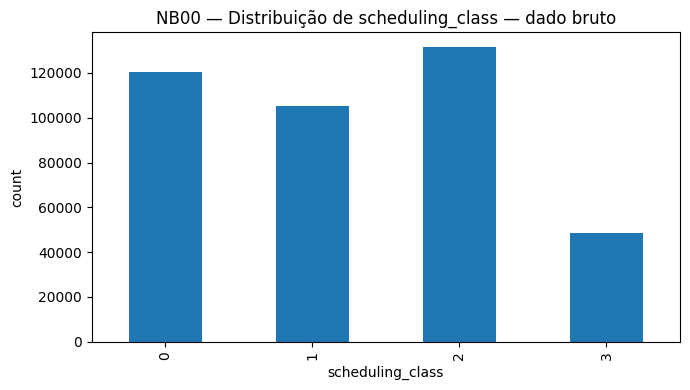

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed_raw/fig_05_scheduling_class.png

===== PRIORITY =====


,mean,median,std,min,max,n_nan
0,147.913793,105.0,116.656489,0.0,450.0,0


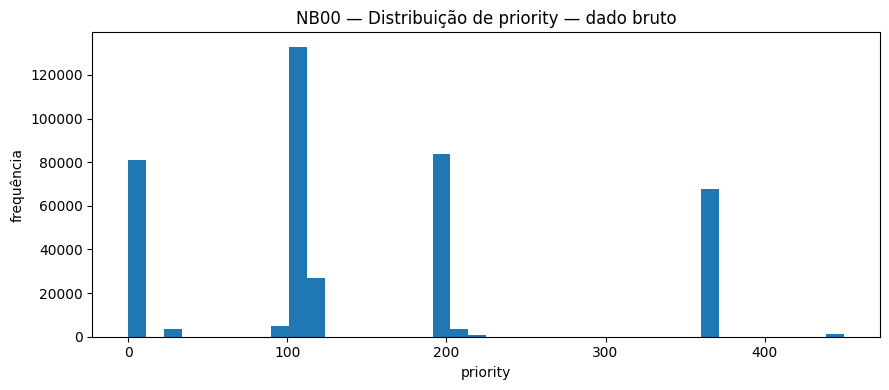

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed_raw/fig_06_priority_hist.png

===== CARDINALIDADE DOS IDENTIFICADORES =====
[NB00_AED] machine_id: 96174 valores únicos, 0 NaN
[NB00_AED] collection_id: 4057 valores únicos, 0 NaN
[NB00_AED] instance_index: 30298 valores únicos, 0 NaN

[Top 10 machine_id por frequência]


,count
machine_id,
6,20
-1,19
44,17
9,14
53,14
49,14
28,12
24,12
21,12


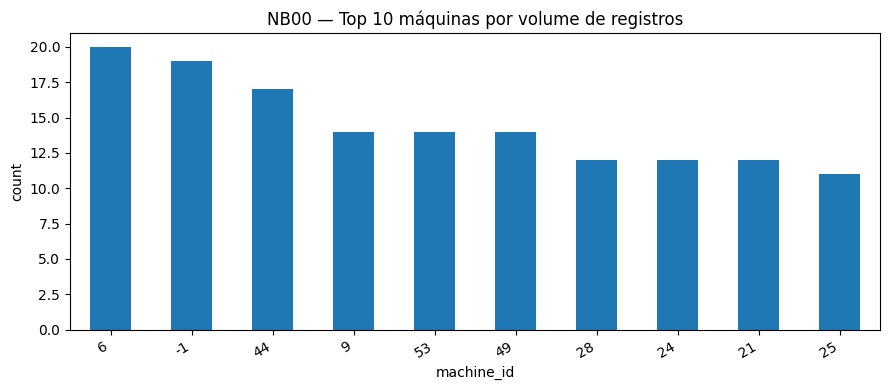

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed_raw/fig_07_top10_machine_id.png

===== ATRIBUTOS DE RECURSO =====
[NB00_AED] resource_request: presença = 99.8%
[NB00_AED] average_usage: presença = 100.0%
[NB00_AED] maximum_usage: presença = 100.0%
[NB00_AED] random_sample_usage: presença = 100.0%
[NB00_AED] assigned_memory: presença = 100.0%
[NB00_AED] page_cache_memory: presença = 100.0%
[NB00_AED] cycles_per_instruction: presença = 69.3%
[NB00_AED] memory_accesses_per_instruction: presença = 69.3%
[NB00_AED] sample_rate: presença = 100.0%


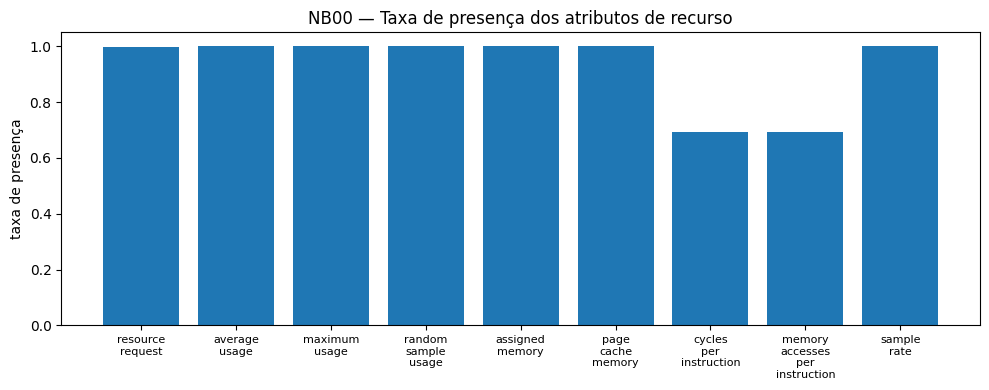

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed_raw/fig_08_resource_presence.png

===== TAXA DE FALHA GLOBAL — APROXIMAÇÃO BRUTA =====
[NB00_AED] Taxa de falha bruta: 0.2283 (22.8%)

[Taxa de falha por scheduling_class]


,fail_rate
scheduling_class,
0,0.145041
1,0.236051
2,0.245472
3,0.371604



===== ESTRUTURA TEMPORAL — EXCLUINDO HOUR == 0 =====
[NB00_AED] Registros sem hour == 0: 349151


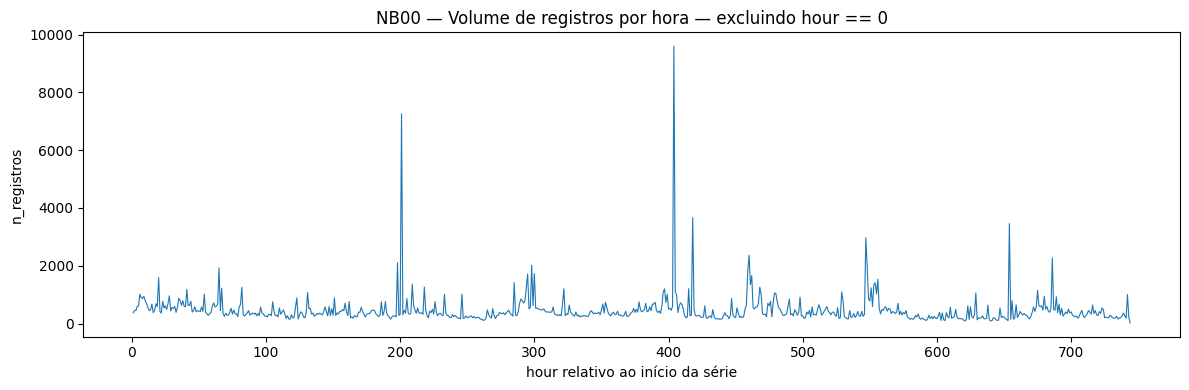

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed_raw/fig_09_volume_por_hora_sem_h0.png

[Distribuição de event excluindo hour == 0]


,count
event,
FINISH,92198
SCHEDULE,68943
LOST,59437
ENABLE,57225
FAIL,55528
EVICT,14756
KILL,948
UPDATE_PENDING,111
QUEUE,4


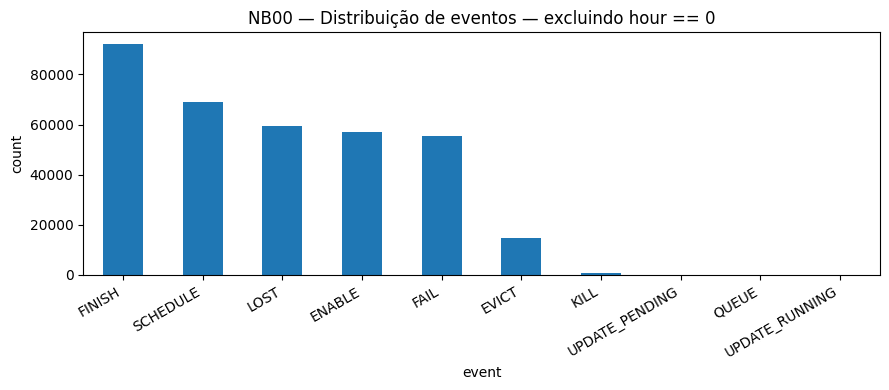

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed_raw/fig_10_event_distribution_no_h0.png

===== CONSISTÊNCIA SEMÂNTICA FAIL vs failed =====
[NB00_AED] event == 'FAIL' AND failed == 1 : 92678
[NB00_AED] event == 'FAIL' AND failed != 1 : 0
[NB00_AED] event != 'FAIL' AND failed == 1 : 0
[NB00_AED] Resumo raw salvo: /content/drive/MyDrive/Mestrado/04-reports/00_aed_raw_summary.json

===== RECRIAÇÃO DO CACHE PARQUET PRÓPRIO DO NB00 =====
[NB00_AED] Cache existente encontrado e será removido: /content/drive/MyDrive/Mestrado/04-reports/00_aed_source_cache.parquet
[NB00_AED] Cache recriado com sucesso: /content/drive/MyDrive/Mestrado/04-reports/00_aed_source_cache.parquet
[NB00_AED] Linhas no cache: 405891
[NB00_AED] Colunas no cache: ['time', 'event', 'failed', 'scheduling_class', 'priority', 'machine_id', 'collection_id', 'instance_index', 'resource_request', 'average_usage', 'maximum_usage', 'random_sample_usage', 'assigned_memory', 'page_cache_memory', '

,primary_input_file,cache_file_generated_by_nb00,uses_downstream_artifacts,rows,cols,columns,time_min,time_max,t_rel_us_min,t_rel_us_max,hour_min,hour_max,bucket_min,bucket_max,window_minutes_exploratory
0,/content/drive/MyDrive/Mestrado/02-datasets/01...,/content/drive/MyDrive/Mestrado/04-reports/00_...,False,405891,17,"[time, event, failed, scheduling_class, priori...",0,2678923967375,0,2678923967375,0,744,0,8929,5



===== AMOSTRA DO CACHE =====


,time,event,failed,scheduling_class,priority,machine_id,collection_id,instance_index,resource_request,average_usage,maximum_usage,random_sample_usage,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate
0,0,FAIL,1,3,200,168846390496,94591244395,144,"{'cpus': 0.020660400390625, 'memory': 0.014434...","{'cpus': 0.00466156005859375, 'memory': 0.0059...","{'cpus': 0.01190185546875, 'memory': 0.0059356...","{'cpus': 0.0043487548828125, 'memory': None}",0.014435,0.000415,NaN,NaN,1.0
1,2517305308183,FAIL,1,2,360,85515092,260697606809,335,"{'cpus': 0.00724029541015625, 'memory': 0.0013...","{'cpus': 0.0, 'memory': 9.5367431640625e-07}","{'cpus': 0.0, 'memory': 9.5367431640625e-07}","{'cpus': 0.0, 'memory': None}",0.000000,0.000000,NaN,NaN,1.0
2,195684022913,SCHEDULE,0,2,103,169321752432,276227177776,376,"{'cpus': 0.048583984375, 'memory': 0.004165649...","{'cpus': 0.024200439453125, 'memory': 0.002788...","{'cpus': 0.06005859375, 'memory': 0.0028457641...","{'cpus': 0.026458740234375, 'memory': None}",0.010422,0.000235,0.939919,0.001318,1.0
3,0,FAIL,1,3,200,178294817221,10507389885,1977,"{'cpus': 0.0704345703125, 'memory': 0.04162597...","{'cpus': 0.047607421875, 'memory': 0.034423828...","{'cpus': 0.13330078125, 'memory': 0.03466796875}","{'cpus': 0.05084228515625, 'memory': None}",0.041626,0.000225,1.359102,0.007643,1.0
4,1810627494172,FINISH,0,2,0,231364893292,25911621841,3907,"{'cpus': 0.00244903564453125, 'memory': 0.0002...","{'cpus': 0.000270843505859375, 'memory': 7.629...","{'cpus': 0.00041484832763671875, 'memory': 7.6...","{'cpus': 0.0003414154052734375, 'memory': None}",0.000272,0.000010,NaN,NaN,1.0



===== MISSINGNESS NO CACHE =====


...

[NB00_AED] Janelas exploratórias de 5 minutos: 8930
[NB00_AED] Janelas vazias: 2 (0.02%)

===== ESTATÍSTICAS DA TAXA DE FALHA — TODAS AS JANELAS =====


,n_windows,mean,std,median,p95,p99,mu_plus_2sigma,critical_windows_mu2sigma,episodes_mu2sigma
0,8930,0.19658,0.140911,0.171875,0.461538,0.636364,0.478401,390,285



===== ESTATÍSTICAS DA TAXA DE FALHA — EXCLUINDO HOUR == 0 =====


,n_windows,mean,std,median,p95,p99,mu_plus_2sigma,critical_windows_mu2sigma,episodes_mu2sigma
0,8918,0.196506,0.140876,0.171429,0.461538,0.63555,0.478257,394,285



===== GERAÇÃO DE FIGURAS DA SÉRIE EXPLORATÓRIA =====


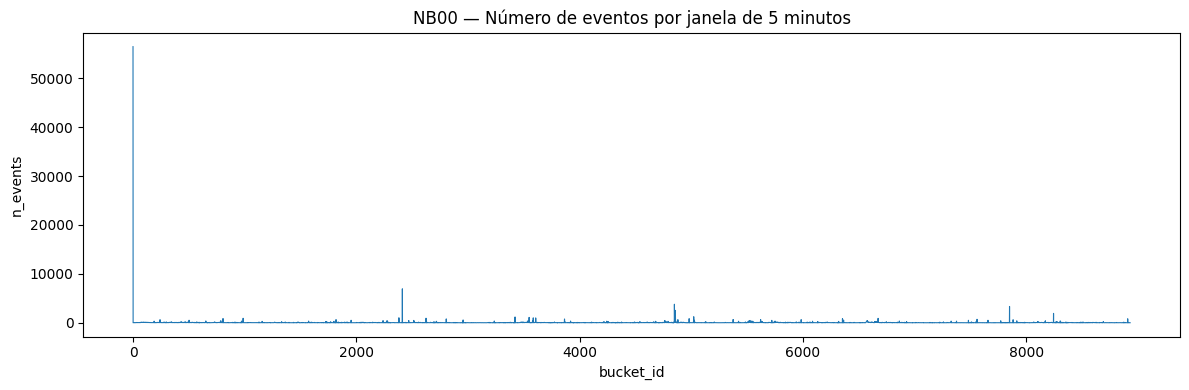

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_01_n_events_por_bucket.png


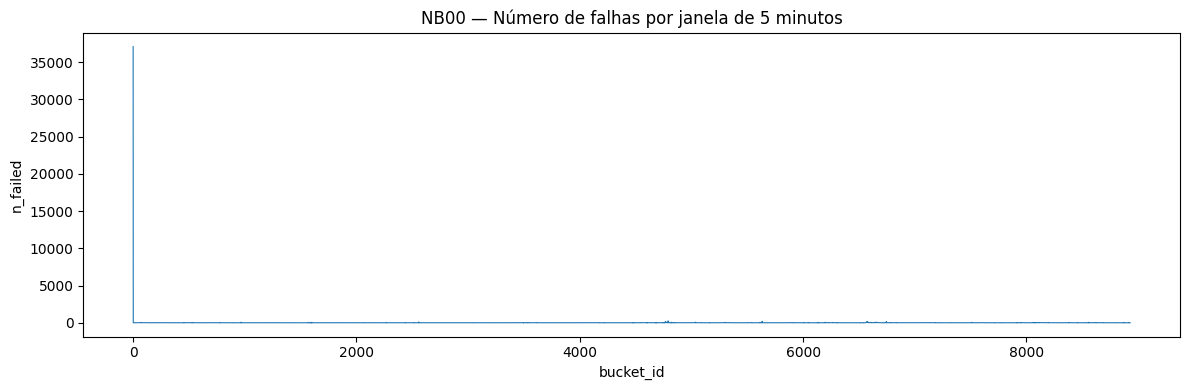

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_02_n_failed_por_bucket.png


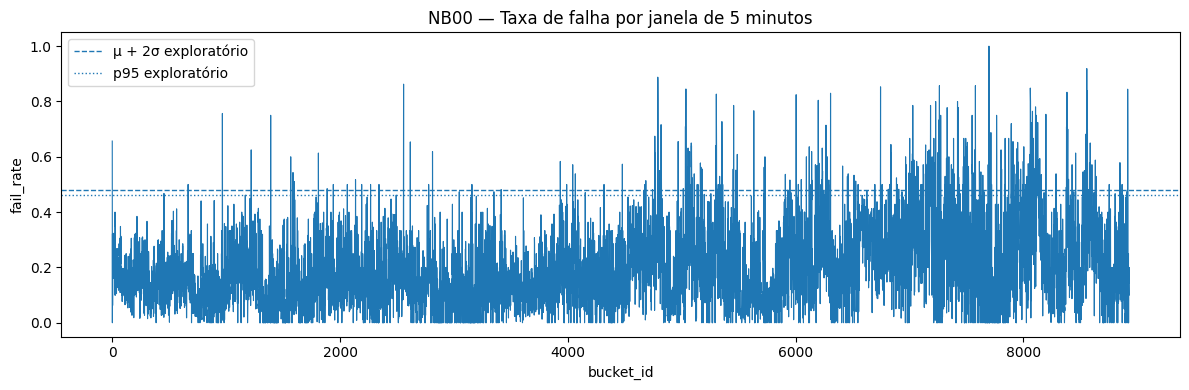

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_03_fail_rate_por_bucket.png


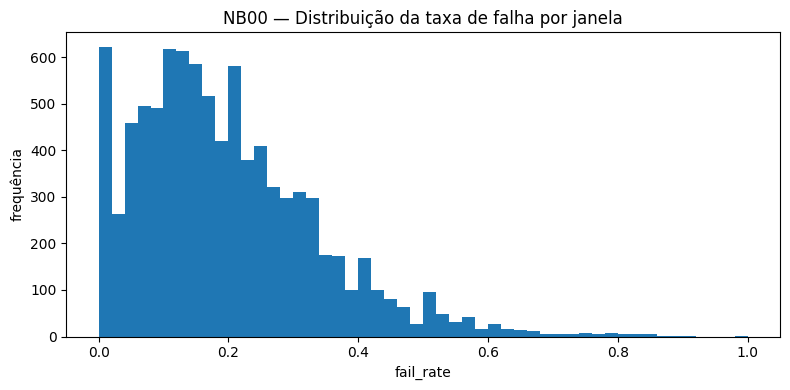

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_04_fail_rate_hist.png


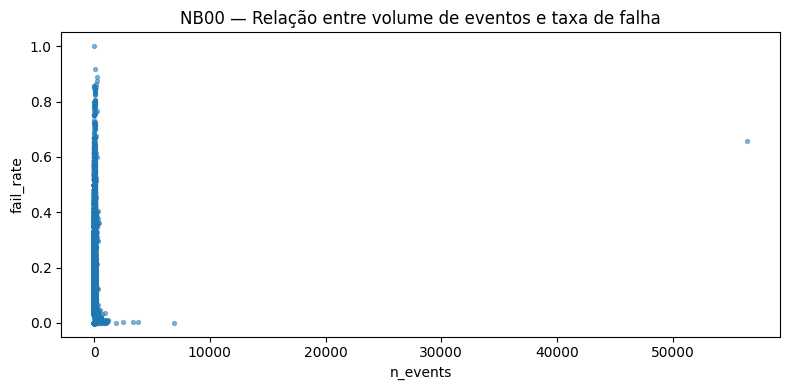

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_05_n_events_vs_fail_rate.png


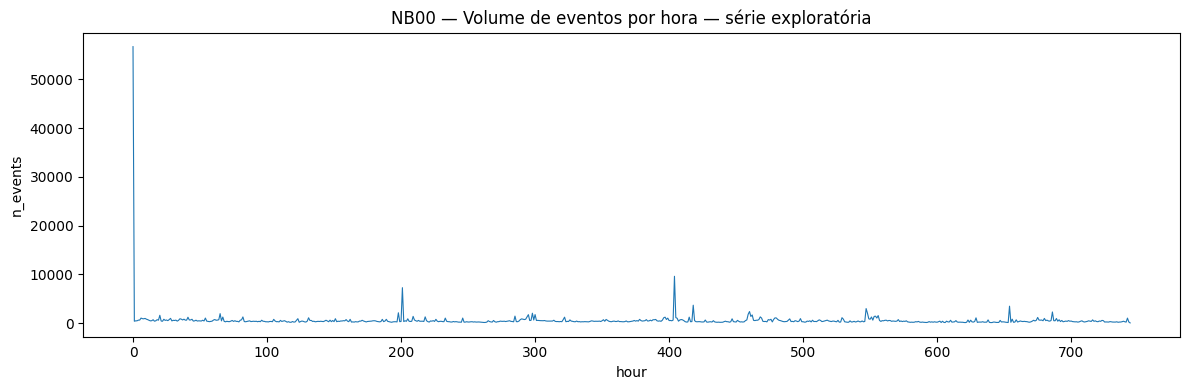

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_06_n_events_por_hora_serie_exploratoria.png


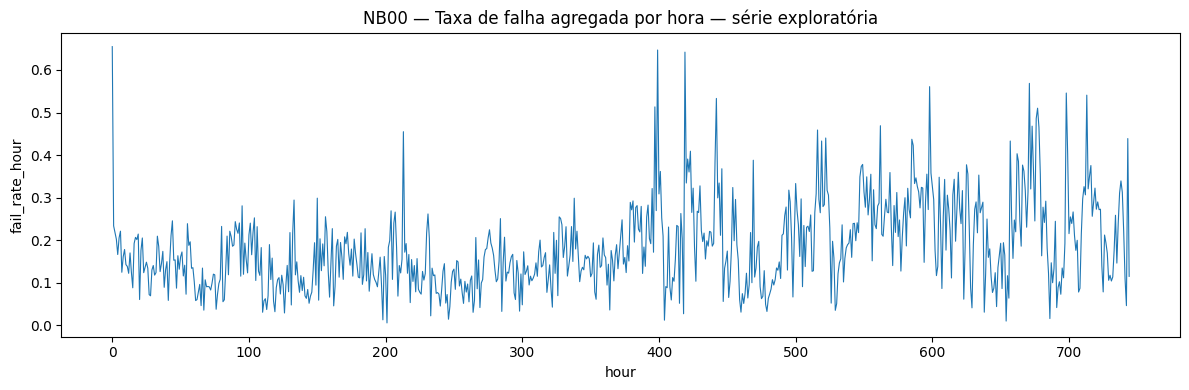

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_07_fail_rate_por_hora_serie_exploratoria.png


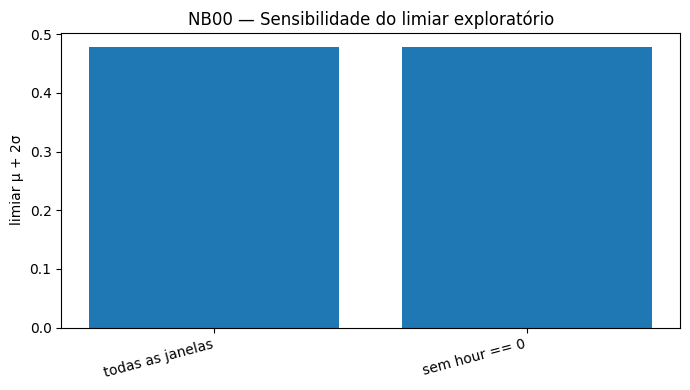

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_08_sensibilidade_limiar_mu_2sigma.png


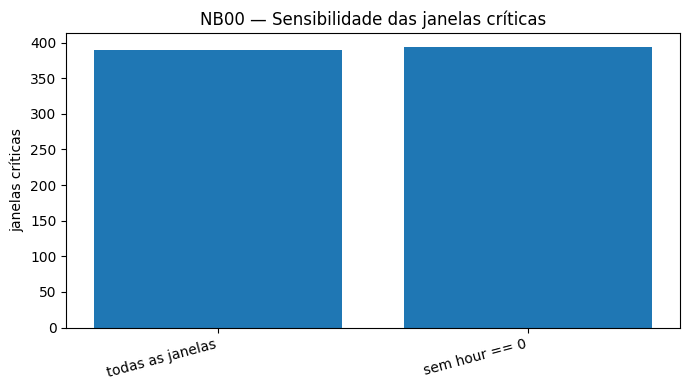

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_09_sensibilidade_janelas_criticas.png


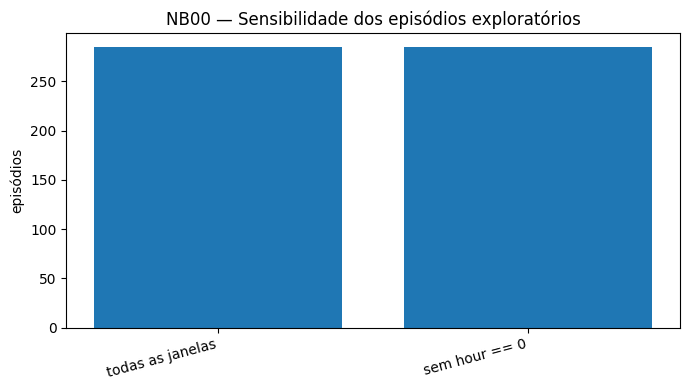

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_10_sensibilidade_episodios.png
[NB00_AED] Série exploratória salva em parquet: /content/drive/MyDrive/Mestrado/04-reports/00_aed_exploratory_5min_series.parquet
[NB00_AED] Série exploratória salva em CSV: /content/drive/MyDrive/Mestrado/04-reports/00_aed_exploratory_5min_series.csv
[NB00_AED] Summary consolidado salvo: /content/drive/MyDrive/Mestrado/04-reports/00_aed_summary.json

RESUMO FINAL — NB00
Entrada primária                 : /content/drive/MyDrive/Mestrado/02-datasets/01-raw/borg_traces_data.csv
Registros brutos carregados      : 405894
Registros temporalmente válidos  : 405891
Colunas no dataset bruto         : 33
Cache recriado pelo NB00         : /content/drive/MyDrive/Mestrado/04-reports/00_aed_source_cache.parquet
Série exploratória 5 min         : /content/drive/MyDrive/Mestrado/04-reports/00_aed_exploratory_5min_series.parquet
Summary raw                      : /content/drive/MyDr

In [1]:
# ============================================================
# NB00 — Análise Exploratória dos Dados Brutos BORG/Kaggle
# Pipeline PPCOMP_DM
#
# CÉLULA ÚNICA CONSOLIDADA
#
# Escopo:
# - Lê diretamente o CSV bruto borg_traces_data.csv
# - Realiza AED estrutural do dataset original
# - Recria o cache parquet próprio do NB00
# - Processa o parquet com DuckDB
# - Gera série exploratória de 5 minutos
# - Gera figuras e summaries JSON
#
# Importante:
# - Não utiliza artefatos de NB01 a NB09
# - O cache 00_aed_source_cache.parquet é sempre recriado
# ============================================================

# -----------------------------
# 0) BOOTSTRAP — Google Drive e repositório
# -----------------------------
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os
import re
import sys
import json
import math
import random
import shutil
import subprocess
import importlib
import warnings
from pathlib import Path
from importlib.machinery import PathFinder

warnings.filterwarnings("ignore")

REPO_DIR = Path("/content/drive/MyDrive/Mestrado/PPCOMP_DM")
GITHUB_REPO = "https://github.com/sergiocostaifes/PPCOMP_DM.git"

if not REPO_DIR.exists():
    REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(["git", "clone", GITHUB_REPO, str(REPO_DIR)], check=True)

repo_str = str(REPO_DIR)
if repo_str in sys.path:
    sys.path.remove(repo_str)
sys.path.insert(0, repo_str)

importlib.invalidate_caches()

if PathFinder not in sys.meta_path:
    sys.meta_path.append(PathFinder)

(REPO_DIR / "src").mkdir(parents=True, exist_ok=True)
init_file = REPO_DIR / "src" / "__init__.py"
if not init_file.exists():
    init_file.write_text("# src package\n", encoding="utf-8")

print("REPO_DIR:", REPO_DIR)

# -----------------------------
# 1) DEPENDÊNCIAS
# -----------------------------
def ensure_package(import_name: str, pip_name: str | None = None) -> None:
    """
    Garante que um pacote esteja disponível no ambiente Colab.
    """
    try:
        importlib.import_module(import_name)
    except ImportError:
        package = pip_name or import_name
        print(f"[NB00] Instalando dependência ausente: {package}")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", package],
            check=True,
        )
        importlib.invalidate_caches()


ensure_package("duckdb")
ensure_package("pyarrow")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import duckdb

from IPython.display import display
from importlib import reload

%matplotlib inline

# -----------------------------
# 2) PATHS DO PROJETO
# -----------------------------
try:
    import src.paths as _paths
    reload(_paths)
    from src.paths import RAW_PATH, REPORTS_PATH, ensure_dirs
    ensure_dirs()
except Exception as e:
    print(f"[NB00] Aviso: não foi possível importar src.paths. Usando paths padrão. Erro: {e}")
    RAW_PATH = Path("/content/drive/MyDrive/Mestrado/02-datasets/01-raw")
    REPORTS_PATH = Path("/content/drive/MyDrive/Mestrado/04-reports")
    RAW_PATH.mkdir(parents=True, exist_ok=True)
    REPORTS_PATH.mkdir(parents=True, exist_ok=True)

CSV_FILE = RAW_PATH / "borg_traces_data.csv"
RAW_FILE = CSV_FILE

RAW_SUMMARY_FILE = REPORTS_PATH / "00_aed_raw_summary.json"
SUMMARY_FILE = REPORTS_PATH / "00_aed_summary.json"
AED_CACHE_FILE = REPORTS_PATH / "00_aed_source_cache.parquet"
EXPLORATORY_SERIES_FILE = REPORTS_PATH / "00_aed_exploratory_5min_series.parquet"
EXPLORATORY_SERIES_CSV_FILE = REPORTS_PATH / "00_aed_exploratory_5min_series.csv"

FIG_DIR_RAW = REPORTS_PATH / "figures_nb00_aed_raw"
FIG_DIR_AED = REPORTS_PATH / "figures_nb00_aed"

FIG_DIR_RAW.mkdir(parents=True, exist_ok=True)
FIG_DIR_AED.mkdir(parents=True, exist_ok=True)

print("RAW_PATH:", RAW_PATH)
print("REPORTS_PATH:", REPORTS_PATH)
print("CSV_FILE:", CSV_FILE)
print("FIG_DIR_RAW:", FIG_DIR_RAW)
print("FIG_DIR_AED:", FIG_DIR_AED)

# -----------------------------
# 3) CONFIGURAÇÕES GERAIS
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

WINDOW_MINUTES = 5
WINDOW_US = WINDOW_MINUTES * 60 * 1_000_000
HOUR_US = 60 * 60 * 1_000_000

# Valor usado para identificar sentinelas/anomalias temporais extremas na AED.
SENTINEL_TIME_CUTOFF = 10_000_000_000_000_000  # 1e16

# Limite máximo de BIGINT, usado como proteção adicional.
MAX_VALID_TIME_EXCLUSIVE = 9_223_372_036_854_775_807

raw_figures: list[str] = []
aed_figures: list[str] = []


def log(msg: str) -> None:
    print(f"[NB00_AED] {msg}")


def save_fig(fig_dir: Path, filename: str, registry: list[str] | None = None) -> str:
    """
    Salva a figura corrente, fecha o canvas e registra o caminho.
    """
    out = fig_dir / filename
    plt.tight_layout()
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    log(f"Figura salva: {out}")

    if registry is not None:
        registry.append(str(out))

    return str(out)


def make_json_safe(obj):
    """
    Converte objetos numpy/pandas em tipos seguros para JSON.
    """
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]

    if isinstance(obj, tuple):
        return [make_json_safe(v) for v in obj]

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, (np.integer,)):
        return int(obj)

    if isinstance(obj, (np.floating,)):
        v = float(obj)
        if math.isnan(v) or math.isinf(v):
            return None
        return v

    if isinstance(obj, float):
        if math.isnan(obj) or math.isinf(obj):
            return None
        return obj

    if obj is None:
        return None

    try:
        if pd.isna(obj):
            return None
    except Exception:
        pass

    return obj


def sql_path(path: Path) -> str:
    """
    Escapa caminho para uso em string SQL.
    """
    return str(path).replace("'", "''")


def sql_literal(value) -> str:
    """
    Escapa literal textual para uso em SQL.
    """
    return "'" + str(value).replace("'", "''") + "'"


def safe_alias(value: str) -> str:
    """
    Gera alias seguro para nomes de colunas derivados de valores textuais.
    """
    value = str(value)
    value = re.sub(r"[^0-9a-zA-Z_]+", "_", value)
    value = value.strip("_")
    if not value:
        value = "UNKNOWN"
    return value


def detect_episodes_from_flag(flag_values) -> dict:
    """
    Detecta episódios como sequências máximas contíguas em que flag == 1.

    Retorna estatísticas simples para AED.
    """
    flags = np.asarray(flag_values).astype(int)

    episodes = []
    in_episode = False
    start = None

    for i, value in enumerate(flags):
        if value == 1 and not in_episode:
            start = i
            in_episode = True
        elif value == 0 and in_episode:
            episodes.append((start, i - 1))
            in_episode = False
            start = None

    if in_episode:
        episodes.append((start, len(flags) - 1))

    durations = [end - start + 1 for start, end in episodes]

    return {
        "n_episodes": int(len(episodes)),
        "n_critical_windows": int(flags.sum()),
        "one_window_episodes": int(sum(1 for d in durations if d == 1)),
        "duration_min": int(min(durations)) if durations else 0,
        "duration_max": int(max(durations)) if durations else 0,
        "duration_mean": float(np.mean(durations)) if durations else 0.0,
        "episodes": [
            {
                "start_index": int(start),
                "end_index": int(end),
                "duration_windows": int(end - start + 1),
            }
            for start, end in episodes
        ],
    }


def fail_rate_stats(series_df: pd.DataFrame, label: str) -> dict:
    """
    Calcula estatísticas exploratórias da taxa de falha.
    """
    fail_rate = series_df["fail_rate"].astype(float)

    mu = float(fail_rate.mean())
    sigma = float(fail_rate.std(ddof=0))
    threshold = mu + 2 * sigma
    p95 = float(fail_rate.quantile(0.95))
    p99 = float(fail_rate.quantile(0.99))

    critical_mu2sigma = fail_rate >= threshold
    critical_p95 = fail_rate >= p95

    episodes_mu2sigma = detect_episodes_from_flag(critical_mu2sigma)
    episodes_p95 = detect_episodes_from_flag(critical_p95)

    return {
        "label": label,
        "n_windows": int(len(series_df)),
        "fail_rate_mean": mu,
        "fail_rate_std": sigma,
        "fail_rate_min": float(fail_rate.min()),
        "fail_rate_max": float(fail_rate.max()),
        "fail_rate_median": float(fail_rate.median()),
        "fail_rate_p95": p95,
        "fail_rate_p99": p99,
        "threshold_mu_plus_2sigma": float(threshold),
        "critical_windows_mu2sigma": int(critical_mu2sigma.sum()),
        "critical_windows_p95": int(critical_p95.sum()),
        "episodes_mu2sigma": episodes_mu2sigma,
        "episodes_p95": episodes_p95,
    }


# ============================================================
# PARTE A — AED DO CSV BRUTO
# ============================================================

# -----------------------------
# 4) LEITURA DO DATASET BRUTO
# -----------------------------
if not CSV_FILE.exists():
    log(f"Arquivo não encontrado: {CSV_FILE}")
    log("Conteúdo de RAW_PATH:")

    try:
        print(os.listdir(RAW_PATH))
    except Exception as e:
        log(f"Falha ao listar RAW_PATH: {e}")

    raise FileNotFoundError(f"Arquivo não encontrado: {CSV_FILE}")

log(f"Arquivo encontrado: {CSV_FILE}")
log(f"Tamanho do arquivo: {round(CSV_FILE.stat().st_size / 1024 / 1024, 1)} MB")

df_raw = pd.read_csv(CSV_FILE, low_memory=False)
df_raw = df_raw.drop(columns=["Unnamed: 0"], errors="ignore")

log(f"Leitura OK: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas")
log(f"Colunas: {list(df_raw.columns)}")

# -----------------------------
# 5) ESTRUTURA GERAL
# -----------------------------
print("\n===== ESTRUTURA GERAL DO DATASET BRUTO =====")
print("shape:", df_raw.shape)

print("\nTipos de dados:")
display(df_raw.dtypes.to_frame("dtype"))

missing = df_raw.isna().sum()
missing_pct = (df_raw.isna().mean() * 100).round(2)

missing_df = pd.DataFrame(
    {
        "missing_count": missing,
        "missing_pct": missing_pct,
    }
)
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values(
    "missing_count",
    ascending=False,
)

print("\nColunas com valores ausentes:")
display(missing_df)

raw_summary = {
    "notebook": "NB00",
    "scope": "AED do dataset bruto BORG/Kaggle",
    "uses_downstream_artifacts": False,
    "raw_file": str(CSV_FILE),
    "raw_file_size_mb": round(CSV_FILE.stat().st_size / 1024 / 1024, 2),
    "raw_rows_loaded": int(df_raw.shape[0]),
    "raw_cols": int(df_raw.shape[1]),
    "columns": list(df_raw.columns),
    "missing_by_column": {
        col: int(cnt) for col, cnt in missing.items() if cnt > 0
    },
    "missing_pct_by_column": {
        col: float(missing_pct[col]) for col in missing_df.index
    },
}

# -----------------------------
# 6) TRATAMENTO TEMPORAL LOCAL
# -----------------------------
df = df_raw.copy()

if "time" not in df.columns:
    raise ValueError("Coluna obrigatória ausente: time")

df["time"] = pd.to_numeric(df["time"], errors="coerce")

n_sentinel = int((df["time"] > SENTINEL_TIME_CUTOFF).sum())
df.loc[df["time"] > SENTINEL_TIME_CUTOFF, "time"] = np.nan

n_time_nan = int(df["time"].isna().sum())

log(f"Registros com time > sentinela ({SENTINEL_TIME_CUTOFF}): {n_sentinel} → convertidos para NaN")
log(f"Total time NaN após tratamento temporal local: {n_time_nan}")

df_t = df.dropna(subset=["time"]).copy()
df_t = df_t[
    (df_t["time"] >= 0)
    & (df_t["time"] < MAX_VALID_TIME_EXCLUSIVE)
].copy()

df_t["time"] = df_t["time"].astype("int64")

t_min = int(df_t["time"].min())
t_max = int(df_t["time"].max())
t_range_us = t_max - t_min

df_t["t_rel_us"] = df_t["time"] - t_min
df_t["bucket_id"] = (df_t["t_rel_us"] // WINDOW_US).astype("int64")
df_t["hour"] = (df_t["t_rel_us"] // HOUR_US).astype("int64")

raw_summary["temporal"] = {
    "time_min": t_min,
    "time_max": t_max,
    "time_range_us": int(t_range_us),
    "time_range_hours": round(t_range_us / HOUR_US, 1),
    "n_rows_time_valid": int(len(df_t)),
    "n_rows_time_nan": int(n_time_nan),
    "n_sentinel_removed": int(n_sentinel),
    "n_buckets_5min_estimated": int(df_t["bucket_id"].max() + 1),
    "n_hours_estimated": int(df_t["hour"].max() + 1),
}

print("\n===== COBERTURA TEMPORAL =====")
print(f"time min: {t_min}")
print(f"time max: {t_max}")
print(f"Duração aproximada: {round(t_range_us / HOUR_US, 1)} horas")
print(f"Janelas de 5 min estimadas: {df_t['bucket_id'].max() + 1}")

hourly_volume = df_t.groupby("hour").size()

print(f"\nVolume mínimo por hora: {hourly_volume.min()}")
print(f"Volume máximo por hora: {hourly_volume.max()}")
print(f"Volume médio por hora : {hourly_volume.mean():.1f}")

raw_summary["temporal"]["hourly_volume_min"] = int(hourly_volume.min())
raw_summary["temporal"]["hourly_volume_max"] = int(hourly_volume.max())
raw_summary["temporal"]["hourly_volume_mean"] = float(hourly_volume.mean())

plt.figure(figsize=(12, 4))
plt.plot(hourly_volume.index, hourly_volume.values, linewidth=0.8)
plt.xlabel("hour relativo ao início da série")
plt.ylabel("n_registros")
plt.title("NB00 — Volume de registros por hora — dado bruto")
save_fig(FIG_DIR_RAW, "fig_01_volume_por_hora.png", raw_figures)

# -----------------------------
# 7) BLOCO INICIAL — hour == 0
# -----------------------------
mask_h0 = df_t["hour"] == 0

n_h0 = int(mask_h0.sum())
pct_h0 = float(mask_h0.mean())

log(f"Registros em hour == 0: {n_h0} ({pct_h0:.1%} do total com time válido)")

raw_summary["hour0"] = {
    "n_rows": n_h0,
    "pct_rows": round(pct_h0, 6),
}

if "event" in df_t.columns:
    h0_event = df_t.loc[mask_h0, "event"].value_counts(dropna=False)
    print("\n[Distribuição de event em hour == 0]")
    display(h0_event.to_frame("count"))
    raw_summary["hour0"]["event_distribution"] = h0_event.to_dict()

if "failed" in df_t.columns:
    failed_h0 = int(
        pd.to_numeric(df_t.loc[mask_h0, "failed"], errors="coerce")
        .fillna(0)
        .astype(int)
        .sum()
    )
    raw_summary["hour0"]["failed_count"] = failed_h0
    log(f"Registros failed == 1 em hour == 0: {failed_h0}")

plt.figure(figsize=(7, 4))
plt.bar(["hour == 0", "demais horas"], [n_h0, int((~mask_h0).sum())])
plt.ylabel("n_registros")
plt.title("NB00 — Comparativo de volume: bloco inicial vs restante")
save_fig(FIG_DIR_RAW, "fig_02_volume_hour0_vs_outros.png", raw_figures)

# -----------------------------
# 8) DISTRIBUIÇÃO DE EVENTOS
# -----------------------------
print("\n===== DISTRIBUIÇÃO DE EVENTOS =====")

if "event" in df.columns:
    event_counts = df["event"].value_counts(dropna=False)
    event_pct = df["event"].value_counts(dropna=False, normalize=True).mul(100)

    event_df = pd.DataFrame(
        {
            "count": event_counts,
            "pct": event_pct,
        }
    )

    display(event_df)

    plt.figure(figsize=(9, 4))
    event_counts.plot(kind="bar")
    plt.xlabel("event")
    plt.ylabel("count")
    plt.title("NB00 — Distribuição de tipos de evento — dado bruto")
    plt.xticks(rotation=30, ha="right")
    save_fig(FIG_DIR_RAW, "fig_03_event_distribution.png", raw_figures)

    raw_summary["event_distribution"] = event_counts.to_dict()
    raw_summary["event_distribution_pct"] = event_pct.to_dict()

# -----------------------------
# 9) DISTRIBUIÇÃO DE FAILED
# -----------------------------
print("\n===== DISTRIBUIÇÃO DE FAILED =====")

if "failed" in df.columns:
    df["failed_num"] = (
        pd.to_numeric(df["failed"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    failed_counts = df["failed_num"].value_counts(dropna=False).sort_index()
    display(failed_counts.to_frame("count"))

    plt.figure(figsize=(6, 4))
    failed_counts.plot(kind="bar")
    plt.xlabel("failed")
    plt.ylabel("count")
    plt.title("NB00 — Distribuição de failed — dado bruto")
    save_fig(FIG_DIR_RAW, "fig_04_failed_distribution.png", raw_figures)

    n_failed_1 = int((df["failed_num"] == 1).sum())
    pct_failed = float(df["failed_num"].mean())

    raw_summary["failed"] = {
        "n_failed_0": int((df["failed_num"] == 0).sum()),
        "n_failed_1": n_failed_1,
        "pct_failed_1": round(pct_failed, 6),
    }

    log(f"Registros failed == 1: {n_failed_1} ({pct_failed:.1%})")

    if "event" in df.columns:
        concord = (df["event"].eq("FAIL") == df["failed_num"].eq(1)).mean()
        raw_summary["failed"]["event_fail_concordance"] = float(concord)
        log(f"Concordância event == 'FAIL' vs failed == 1: {concord:.4f}")

# -----------------------------
# 10) SCHEDULING CLASS
# -----------------------------
print("\n===== SCHEDULING CLASS =====")

if "scheduling_class" in df.columns:
    sched_counts = df["scheduling_class"].value_counts(dropna=False).sort_index()
    sched_pct = (
        df["scheduling_class"]
        .value_counts(dropna=False, normalize=True)
        .reindex(sched_counts.index)
        .mul(100)
    )

    display(
        pd.DataFrame(
            {
                "count": sched_counts,
                "pct": sched_pct,
            }
        )
    )

    plt.figure(figsize=(7, 4))
    sched_counts.plot(kind="bar")
    plt.xlabel("scheduling_class")
    plt.ylabel("count")
    plt.title("NB00 — Distribuição de scheduling_class — dado bruto")
    save_fig(FIG_DIR_RAW, "fig_05_scheduling_class.png", raw_figures)

    raw_summary["scheduling_class_distribution"] = {
        str(k): int(v) for k, v in sched_counts.items()
    }
    raw_summary["scheduling_class_distribution_pct"] = {
        str(k): float(v) for k, v in sched_pct.items()
    }

# -----------------------------
# 11) PRIORITY
# -----------------------------
print("\n===== PRIORITY =====")

if "priority" in df.columns:
    priority_num = pd.to_numeric(df["priority"], errors="coerce")

    priority_stats = {
        "mean": float(priority_num.mean()),
        "median": float(priority_num.median()),
        "std": float(priority_num.std(ddof=0)),
        "min": float(priority_num.min()),
        "max": float(priority_num.max()),
        "n_nan": int(priority_num.isna().sum()),
    }

    display(pd.DataFrame([priority_stats]))

    plt.figure(figsize=(9, 4))
    plt.hist(priority_num.dropna(), bins=40)
    plt.xlabel("priority")
    plt.ylabel("frequência")
    plt.title("NB00 — Distribuição de priority — dado bruto")
    save_fig(FIG_DIR_RAW, "fig_06_priority_hist.png", raw_figures)

    raw_summary["priority"] = priority_stats

# -----------------------------
# 12) CARDINALIDADE DOS IDENTIFICADORES
# -----------------------------
print("\n===== CARDINALIDADE DOS IDENTIFICADORES =====")

id_cols = ["machine_id", "collection_id", "instance_index"]
cardinality = {}

for col in id_cols:
    if col in df.columns:
        n_unique = int(df[col].nunique(dropna=True))
        n_nan = int(df[col].isna().sum())

        cardinality[col] = {
            "n_unique": n_unique,
            "n_nan": n_nan,
        }

        log(f"{col}: {n_unique} valores únicos, {n_nan} NaN")

raw_summary["cardinality"] = cardinality

if "machine_id" in df.columns:
    top_machines = df["machine_id"].value_counts(dropna=False).head(10)

    print("\n[Top 10 machine_id por frequência]")
    display(top_machines.to_frame("count"))

    plt.figure(figsize=(9, 4))
    top_machines.plot(kind="bar")
    plt.xlabel("machine_id")
    plt.ylabel("count")
    plt.title("NB00 — Top 10 máquinas por volume de registros")
    plt.xticks(rotation=30, ha="right")
    save_fig(FIG_DIR_RAW, "fig_07_top10_machine_id.png", raw_figures)

# -----------------------------
# 13) ATRIBUTOS DE RECURSO
# -----------------------------
print("\n===== ATRIBUTOS DE RECURSO =====")

resource_cols = [
    "resource_request",
    "average_usage",
    "maximum_usage",
    "random_sample_usage",
    "assigned_memory",
    "page_cache_memory",
    "cycles_per_instruction",
    "memory_accesses_per_instruction",
    "sample_rate",
]

resource_summary = {}

for col in resource_cols:
    if col in df.columns:
        presence = float(df[col].notna().mean())

        resource_summary[col] = {
            "presence_rate": round(presence, 6),
            "missing_count": int(df[col].isna().sum()),
        }

        log(f"{col}: presença = {presence:.1%}")

raw_summary["resource_presence"] = resource_summary

if resource_summary:
    cols_r = list(resource_summary.keys())
    rates = [resource_summary[c]["presence_rate"] for c in cols_r]

    plt.figure(figsize=(10, 4))
    plt.bar(range(len(cols_r)), rates)
    plt.xticks(
        range(len(cols_r)),
        [c.replace("_", "\n") for c in cols_r],
        fontsize=8,
    )
    plt.ylabel("taxa de presença")
    plt.ylim(0, 1.05)
    plt.title("NB00 — Taxa de presença dos atributos de recurso")
    save_fig(FIG_DIR_RAW, "fig_08_resource_presence.png", raw_figures)

# -----------------------------
# 14) TAXA DE FALHA GLOBAL BRUTA
# -----------------------------
print("\n===== TAXA DE FALHA GLOBAL — APROXIMAÇÃO BRUTA =====")

if "failed_num" in df.columns:
    n_total_valid = int(df["failed_num"].notna().sum())
    n_fail = int((df["failed_num"] == 1).sum())

    fail_rate_raw = n_fail / n_total_valid if n_total_valid > 0 else float("nan")

    log(f"Taxa de falha bruta: {fail_rate_raw:.4f} ({fail_rate_raw:.1%})")

    raw_summary["fail_rate_raw_global"] = round(fail_rate_raw, 6)

    if "scheduling_class" in df.columns:
        fail_by_class = (
            df.groupby("scheduling_class")["failed_num"]
            .mean()
            .rename("fail_rate")
        )

        print("\n[Taxa de falha por scheduling_class]")
        display(fail_by_class.to_frame())

        raw_summary["fail_rate_by_scheduling_class"] = {
            str(k): round(float(v), 6) for k, v in fail_by_class.items()
        }

# -----------------------------
# 15) ESTRUTURA TEMPORAL SEM HOUR == 0
# -----------------------------
print("\n===== ESTRUTURA TEMPORAL — EXCLUINDO HOUR == 0 =====")

df_no_h0 = df_t[~mask_h0].copy()

log(f"Registros sem hour == 0: {len(df_no_h0)}")

hourly_no_h0 = df_no_h0.groupby("hour").size()

if len(hourly_no_h0) > 0:
    raw_summary["temporal"]["hourly_no_h0_min"] = int(hourly_no_h0.min())
    raw_summary["temporal"]["hourly_no_h0_max"] = int(hourly_no_h0.max())
    raw_summary["temporal"]["hourly_no_h0_mean"] = float(hourly_no_h0.mean())

    plt.figure(figsize=(12, 4))
    plt.plot(hourly_no_h0.index, hourly_no_h0.values, linewidth=0.8)
    plt.xlabel("hour relativo ao início da série")
    plt.ylabel("n_registros")
    plt.title("NB00 — Volume de registros por hora — excluindo hour == 0")
    save_fig(FIG_DIR_RAW, "fig_09_volume_por_hora_sem_h0.png", raw_figures)

if "event" in df_no_h0.columns:
    event_no_h0 = df_no_h0["event"].value_counts(dropna=False)

    print("\n[Distribuição de event excluindo hour == 0]")
    display(event_no_h0.to_frame("count"))

    raw_summary["event_distribution_no_h0"] = event_no_h0.to_dict()

    plt.figure(figsize=(9, 4))
    event_no_h0.plot(kind="bar")
    plt.xlabel("event")
    plt.ylabel("count")
    plt.title("NB00 — Distribuição de eventos — excluindo hour == 0")
    plt.xticks(rotation=30, ha="right")
    save_fig(FIG_DIR_RAW, "fig_10_event_distribution_no_h0.png", raw_figures)

# -----------------------------
# 16) CONSISTÊNCIA SEMÂNTICA FAIL / failed
# -----------------------------
print("\n===== CONSISTÊNCIA SEMÂNTICA FAIL vs failed =====")

if "event" in df.columns and "failed_num" in df.columns:
    mask_fail_event = df["event"] == "FAIL"
    mask_failed_1 = df["failed_num"] == 1

    n_fail_event_only = int((mask_fail_event & ~mask_failed_1).sum())
    n_failed_1_only = int((~mask_fail_event & mask_failed_1).sum())
    n_concordant = int((mask_fail_event & mask_failed_1).sum())

    log(f"event == 'FAIL' AND failed == 1 : {n_concordant}")
    log(f"event == 'FAIL' AND failed != 1 : {n_fail_event_only}")
    log(f"event != 'FAIL' AND failed == 1 : {n_failed_1_only}")

    raw_summary["semantic_consistency"] = {
        "event_fail_and_failed_1": n_concordant,
        "event_fail_only": n_fail_event_only,
        "failed_1_only": n_failed_1_only,
        "full_concordance": bool(
            n_fail_event_only == 0 and n_failed_1_only == 0
        ),
    }

# -----------------------------
# 17) PERSISTÊNCIA DO SUMMARY RAW
# -----------------------------
raw_summary["figures_raw"] = raw_figures

RAW_SUMMARY_FILE.write_text(
    json.dumps(make_json_safe(raw_summary), indent=2, ensure_ascii=False),
    encoding="utf-8",
)

log(f"Resumo raw salvo: {RAW_SUMMARY_FILE}")

# ============================================================
# PARTE B — RECRIAÇÃO DO PARQUET E AED MEMORY-SAFE COM DUCKDB
# ============================================================

# -----------------------------
# 18) RECRIAÇÃO DO CACHE PARQUET PRÓPRIO DO NB00
# -----------------------------
print("\n===== RECRIAÇÃO DO CACHE PARQUET PRÓPRIO DO NB00 =====")

assert RAW_FILE.exists(), f"Arquivo bruto não encontrado: {RAW_FILE}"

# O cache contém as colunas necessárias para a AED temporal/agregada.
# Mantém-se a origem exclusiva no CSV bruto já carregado neste NB00.
cache_candidate_cols = [
    "time",
    "event",
    "failed",
    "scheduling_class",
    "priority",
    "machine_id",
    "collection_id",
    "instance_index",
    "resource_request",
    "average_usage",
    "maximum_usage",
    "random_sample_usage",
    "assigned_memory",
    "page_cache_memory",
    "cycles_per_instruction",
    "memory_accesses_per_instruction",
    "sample_rate",
]

cache_cols = [col for col in cache_candidate_cols if col in df.columns]

df_cache = df.loc[
    df["time"].notna()
    & (df["time"] >= 0)
    & (df["time"] < MAX_VALID_TIME_EXCLUSIVE),
    cache_cols,
].copy()

df_cache["time"] = pd.to_numeric(
    df_cache["time"],
    errors="coerce",
).astype("int64")

for col in [
    "failed",
    "scheduling_class",
    "priority",
    "machine_id",
    "collection_id",
    "instance_index",
]:
    if col in df_cache.columns:
        df_cache[col] = pd.to_numeric(
            df_cache[col],
            errors="coerce",
        ).astype("Int64")

for col in [
    "assigned_memory",
    "page_cache_memory",
    "cycles_per_instruction",
    "memory_accesses_per_instruction",
    "sample_rate",
]:
    if col in df_cache.columns:
        df_cache[col] = pd.to_numeric(df_cache[col], errors="coerce")

for col in df_cache.select_dtypes(include=["object"]).columns:
    df_cache[col] = df_cache[col].astype("string")

if AED_CACHE_FILE.exists():
    log(f"Cache existente encontrado e será removido: {AED_CACHE_FILE}")
    AED_CACHE_FILE.unlink()
else:
    log(f"Cache ainda não existe; será criado a partir do CSV bruto: {AED_CACHE_FILE}")

df_cache.to_parquet(
    AED_CACHE_FILE,
    index=False,
    compression="snappy",
)

assert AED_CACHE_FILE.exists(), f"Falha na criação do cache NB00: {AED_CACHE_FILE}"

log(f"Cache recriado com sucesso: {AED_CACHE_FILE}")
log(f"Linhas no cache: {len(df_cache)}")
log(f"Colunas no cache: {list(df_cache.columns)}")

# Libera referência auxiliar mais pesada.
del df_cache

# -----------------------------
# 19) CONEXÃO DUCKDB E VIEW SOBRE O CACHE
# -----------------------------
con = duckdb.connect(database=":memory:")
con.execute("PRAGMA threads=1;")

cache_path_sql = sql_path(AED_CACHE_FILE)

con.execute(f"""
CREATE OR REPLACE VIEW cache AS
SELECT *
FROM read_parquet('{cache_path_sql}')
WHERE time IS NOT NULL
  AND time >= 0
  AND time < {MAX_VALID_TIME_EXCLUSIVE};
""")

schema_df = con.execute("DESCRIBE cache").df()
cache_columns = schema_df["column_name"].tolist()

print("\n===== COLUNAS NO CACHE NB00 =====")
print(cache_columns)

required_cols = {"time", "event", "failed"}
missing_required = required_cols - set(cache_columns)

assert not missing_required, f"Colunas obrigatórias ausentes no cache: {missing_required}"

has_priority = "priority" in cache_columns
has_scheduling = "scheduling_class" in cache_columns
has_machine = "machine_id" in cache_columns
has_collection = "collection_id" in cache_columns

# -----------------------------
# 20) SUMÁRIO ESTRUTURAL DO CACHE
# -----------------------------
basic_info = con.execute(f"""
SELECT
    COUNT(*) AS rows,
    MIN(time) AS time_min,
    MAX(time) AS time_max,
    CAST(FLOOR((MAX(time) - MIN(time)) / {HOUR_US}) AS BIGINT) AS hour_max,
    CAST(FLOOR((MAX(time) - MIN(time)) / {WINDOW_US}) AS BIGINT) AS bucket_max
FROM cache;
""").df().iloc[0].to_dict()

rows_total = int(basic_info["rows"])
time_min = int(basic_info["time_min"])
time_max = int(basic_info["time_max"])
hour_max = int(basic_info["hour_max"])
bucket_max = int(basic_info["bucket_max"])

if bucket_max > 1_000_000:
    raise ValueError(
        f"bucket_max anormalmente alto: {bucket_max}. "
        "Provável presença de valor sentinela/extremo em time."
    )

cache_summary = {
    "primary_input_file": str(RAW_FILE),
    "cache_file_generated_by_nb00": str(AED_CACHE_FILE),
    "uses_downstream_artifacts": False,
    "rows": rows_total,
    "cols": int(len(cache_columns)),
    "columns": cache_columns,
    "time_min": time_min,
    "time_max": time_max,
    "t_rel_us_min": 0,
    "t_rel_us_max": int(time_max - time_min),
    "hour_min": 0,
    "hour_max": hour_max,
    "bucket_min": 0,
    "bucket_max": bucket_max,
    "window_minutes_exploratory": int(WINDOW_MINUTES),
}

print("\n===== SUMÁRIO ESTRUTURAL DO CACHE =====")
display(pd.DataFrame([cache_summary]))

sample_df = con.execute("""
SELECT *
FROM cache
LIMIT 5;
""").df()

print("\n===== AMOSTRA DO CACHE =====")
display(sample_df)

# -----------------------------
# 21) MISSINGNESS NO CACHE
# -----------------------------
print("\n===== MISSINGNESS NO CACHE =====")

missing_rows = []

for col in cache_columns:
    query = f"""
    SELECT
        COUNT(*) AS total,
        SUM(CASE WHEN "{col}" IS NULL THEN 1 ELSE 0 END) AS missing_count
    FROM cache;
    """
    r = con.execute(query).df().iloc[0].to_dict()

    total = int(r["total"])
    missing_count = int(r["missing_count"] or 0)

    missing_rows.append(
        {
            "column": col,
            "missing_count": missing_count,
            "missing_rate": float(missing_count / total) if total > 0 else 0.0,
        }
    )

missing_cache_df = pd.DataFrame(missing_rows).sort_values(
    ["missing_count", "column"],
    ascending=[False, True],
)

display(missing_cache_df[missing_cache_df["missing_count"] > 0])

cache_summary["missing_cache"] = missing_cache_df.to_dict(orient="records")

# -----------------------------
# 22) VIEW ENRIQUECIDA COM BUCKET E HOUR
# -----------------------------
con.execute(f"""
CREATE OR REPLACE VIEW enriched AS
SELECT
    *,
    CAST(time - {time_min} AS BIGINT) AS t_rel_us,
    CAST(FLOOR((time - {time_min}) / {WINDOW_US}) AS BIGINT) AS bucket_id,
    CAST(FLOOR((time - {time_min}) / {HOUR_US}) AS BIGINT) AS hour
FROM cache;
""")

# -----------------------------
# 23) DISTRIBUIÇÃO DE EVENTOS PELO PARQUET
# -----------------------------
print("\n===== DISTRIBUIÇÃO DE EVENTOS — VIA PARQUET =====")

event_cache_df = con.execute("""
SELECT
    event,
    COUNT(*) AS count,
    COUNT(*) * 100.0 / SUM(COUNT(*)) OVER () AS pct
FROM enriched
GROUP BY event
ORDER BY count DESC;
""").df()

display(event_cache_df)

cache_summary["event_distribution_cache"] = event_cache_df.to_dict(orient="records")

# -----------------------------
# 24) AGREGAÇÃO EXPLORATÓRIA EM JANELAS DE 5 MINUTOS
# -----------------------------
print("\n===== AGREGAÇÃO EXPLORATÓRIA EM JANELAS DE 5 MINUTOS =====")

event_values = [
    row[0]
    for row in con.execute("""
        SELECT DISTINCT event
        FROM enriched
        WHERE event IS NOT NULL
        ORDER BY event;
    """).fetchall()
]

agg_exprs = [
    "COUNT(*) AS n_events",
    "SUM(CASE WHEN failed = 1 THEN 1 ELSE 0 END) AS n_failed",
]

if has_machine:
    agg_exprs.append("COUNT(DISTINCT machine_id) AS n_machines")

if has_collection:
    agg_exprs.append("COUNT(DISTINCT collection_id) AS n_collections")

if has_priority:
    agg_exprs.append("AVG(CAST(priority AS DOUBLE)) AS mean_priority")

if has_scheduling:
    agg_exprs.append("AVG(CAST(scheduling_class AS DOUBLE)) AS mean_scheduling_class")

for ev in event_values:
    alias = f"event_{safe_alias(ev)}_count"
    agg_exprs.append(
        f"SUM(CASE WHEN event = {sql_literal(ev)} THEN 1 ELSE 0 END) AS {alias}"
    )

agg_sql = ",\n    ".join(agg_exprs)

observed_series_df = con.execute(f"""
SELECT
    bucket_id,
    MIN(time) AS bucket_time_min,
    MAX(time) AS bucket_time_max,
    {agg_sql}
FROM enriched
GROUP BY bucket_id
ORDER BY bucket_id;
""").df()

full_buckets_df = pd.DataFrame(
    {
        "bucket_id": np.arange(bucket_max + 1, dtype=np.int64)
    }
)

series_df = full_buckets_df.merge(
    observed_series_df,
    on="bucket_id",
    how="left",
)

series_df["bucket_start_us"] = time_min + series_df["bucket_id"] * WINDOW_US
series_df["bucket_end_us"] = series_df["bucket_start_us"] + WINDOW_US
series_df["hour"] = (series_df["bucket_id"] * WINDOW_US // HOUR_US).astype(int)

count_like_cols = [
    col
    for col in series_df.columns
    if col in ["n_events", "n_failed", "n_machines", "n_collections"]
    or col.startswith("event_")
]

for col in count_like_cols:
    series_df[col] = series_df[col].fillna(0).astype(int)

for col in ["mean_priority", "mean_scheduling_class"]:
    if col in series_df.columns:
        series_df[col] = pd.to_numeric(series_df[col], errors="coerce")

series_df["fail_rate"] = np.where(
    series_df["n_events"] > 0,
    series_df["n_failed"] / series_df["n_events"],
    0.0,
)

series_df["is_empty_bucket"] = (series_df["n_events"] == 0).astype(int)

print("Série exploratória:", series_df.shape)
display(series_df.head())

empty_buckets = int(series_df["is_empty_bucket"].sum())
empty_rate = float(series_df["is_empty_bucket"].mean())

log(f"Janelas exploratórias de 5 minutos: {len(series_df)}")
log(f"Janelas vazias: {empty_buckets} ({empty_rate:.2%})")

# -----------------------------
# 25) ESTATÍSTICAS DA SÉRIE EXPLORATÓRIA
# -----------------------------
series_stats_all = fail_rate_stats(series_df, "all_windows")
series_stats_no_h0 = fail_rate_stats(
    series_df[series_df["hour"] != 0].copy(),
    "excluding_hour0",
)

threshold_mu2sigma = series_stats_all["threshold_mu_plus_2sigma"]
p95 = series_stats_all["fail_rate_p95"]

series_df["is_critical_mu2sigma_exploratory"] = (
    series_df["fail_rate"] >= threshold_mu2sigma
).astype(int)

series_df["is_critical_p95_exploratory"] = (
    series_df["fail_rate"] >= p95
).astype(int)

print("\n===== ESTATÍSTICAS DA TAXA DE FALHA — TODAS AS JANELAS =====")
display(
    pd.DataFrame(
        [
            {
                "n_windows": series_stats_all["n_windows"],
                "mean": series_stats_all["fail_rate_mean"],
                "std": series_stats_all["fail_rate_std"],
                "median": series_stats_all["fail_rate_median"],
                "p95": series_stats_all["fail_rate_p95"],
                "p99": series_stats_all["fail_rate_p99"],
                "mu_plus_2sigma": series_stats_all["threshold_mu_plus_2sigma"],
                "critical_windows_mu2sigma": series_stats_all["critical_windows_mu2sigma"],
                "episodes_mu2sigma": series_stats_all["episodes_mu2sigma"]["n_episodes"],
            }
        ]
    )
)

print("\n===== ESTATÍSTICAS DA TAXA DE FALHA — EXCLUINDO HOUR == 0 =====")
display(
    pd.DataFrame(
        [
            {
                "n_windows": series_stats_no_h0["n_windows"],
                "mean": series_stats_no_h0["fail_rate_mean"],
                "std": series_stats_no_h0["fail_rate_std"],
                "median": series_stats_no_h0["fail_rate_median"],
                "p95": series_stats_no_h0["fail_rate_p95"],
                "p99": series_stats_no_h0["fail_rate_p99"],
                "mu_plus_2sigma": series_stats_no_h0["threshold_mu_plus_2sigma"],
                "critical_windows_mu2sigma": series_stats_no_h0["critical_windows_mu2sigma"],
                "episodes_mu2sigma": series_stats_no_h0["episodes_mu2sigma"]["n_episodes"],
            }
        ]
    )
)

# -----------------------------
# 26) FIGURAS DA SÉRIE EXPLORATÓRIA
# -----------------------------
print("\n===== GERAÇÃO DE FIGURAS DA SÉRIE EXPLORATÓRIA =====")

plt.figure(figsize=(12, 4))
plt.plot(series_df["bucket_id"], series_df["n_events"], linewidth=0.8)
plt.xlabel("bucket_id")
plt.ylabel("n_events")
plt.title("NB00 — Número de eventos por janela de 5 minutos")
save_fig(FIG_DIR_AED, "fig_01_n_events_por_bucket.png", aed_figures)

plt.figure(figsize=(12, 4))
plt.plot(series_df["bucket_id"], series_df["n_failed"], linewidth=0.8)
plt.xlabel("bucket_id")
plt.ylabel("n_failed")
plt.title("NB00 — Número de falhas por janela de 5 minutos")
save_fig(FIG_DIR_AED, "fig_02_n_failed_por_bucket.png", aed_figures)

plt.figure(figsize=(12, 4))
plt.plot(series_df["bucket_id"], series_df["fail_rate"], linewidth=0.8)
plt.axhline(
    threshold_mu2sigma,
    linestyle="--",
    linewidth=1,
    label="µ + 2σ exploratório",
)
plt.axhline(
    p95,
    linestyle=":",
    linewidth=1,
    label="p95 exploratório",
)
plt.xlabel("bucket_id")
plt.ylabel("fail_rate")
plt.title("NB00 — Taxa de falha por janela de 5 minutos")
plt.legend()
save_fig(FIG_DIR_AED, "fig_03_fail_rate_por_bucket.png", aed_figures)

plt.figure(figsize=(8, 4))
plt.hist(series_df["fail_rate"], bins=50)
plt.xlabel("fail_rate")
plt.ylabel("frequência")
plt.title("NB00 — Distribuição da taxa de falha por janela")
save_fig(FIG_DIR_AED, "fig_04_fail_rate_hist.png", aed_figures)

plt.figure(figsize=(8, 4))
plt.scatter(series_df["n_events"], series_df["fail_rate"], s=8, alpha=0.5)
plt.xlabel("n_events")
plt.ylabel("fail_rate")
plt.title("NB00 — Relação entre volume de eventos e taxa de falha")
save_fig(FIG_DIR_AED, "fig_05_n_events_vs_fail_rate.png", aed_figures)

hourly_series_df = series_df.groupby("hour", as_index=False).agg(
    n_events=("n_events", "sum"),
    n_failed=("n_failed", "sum"),
    n_buckets=("bucket_id", "count"),
)

hourly_series_df["fail_rate_hour"] = np.where(
    hourly_series_df["n_events"] > 0,
    hourly_series_df["n_failed"] / hourly_series_df["n_events"],
    0.0,
)

plt.figure(figsize=(12, 4))
plt.plot(hourly_series_df["hour"], hourly_series_df["n_events"], linewidth=0.8)
plt.xlabel("hour")
plt.ylabel("n_events")
plt.title("NB00 — Volume de eventos por hora — série exploratória")
save_fig(FIG_DIR_AED, "fig_06_n_events_por_hora_serie_exploratoria.png", aed_figures)

plt.figure(figsize=(12, 4))
plt.plot(hourly_series_df["hour"], hourly_series_df["fail_rate_hour"], linewidth=0.8)
plt.xlabel("hour")
plt.ylabel("fail_rate_hour")
plt.title("NB00 — Taxa de falha agregada por hora — série exploratória")
save_fig(FIG_DIR_AED, "fig_07_fail_rate_por_hora_serie_exploratoria.png", aed_figures)

sensitivity_plot_df = pd.DataFrame(
    [
        {
            "cenário": "todas as janelas",
            "limiar_mu_2sigma": series_stats_all["threshold_mu_plus_2sigma"],
            "janelas_críticas": series_stats_all["critical_windows_mu2sigma"],
            "episódios": series_stats_all["episodes_mu2sigma"]["n_episodes"],
        },
        {
            "cenário": "sem hour == 0",
            "limiar_mu_2sigma": series_stats_no_h0["threshold_mu_plus_2sigma"],
            "janelas_críticas": series_stats_no_h0["critical_windows_mu2sigma"],
            "episódios": series_stats_no_h0["episodes_mu2sigma"]["n_episodes"],
        },
    ]
)

plt.figure(figsize=(7, 4))
plt.bar(sensitivity_plot_df["cenário"], sensitivity_plot_df["limiar_mu_2sigma"])
plt.ylabel("limiar µ + 2σ")
plt.title("NB00 — Sensibilidade do limiar exploratório")
plt.xticks(rotation=15, ha="right")
save_fig(FIG_DIR_AED, "fig_08_sensibilidade_limiar_mu_2sigma.png", aed_figures)

plt.figure(figsize=(7, 4))
plt.bar(sensitivity_plot_df["cenário"], sensitivity_plot_df["janelas_críticas"])
plt.ylabel("janelas críticas")
plt.title("NB00 — Sensibilidade das janelas críticas")
plt.xticks(rotation=15, ha="right")
save_fig(FIG_DIR_AED, "fig_09_sensibilidade_janelas_criticas.png", aed_figures)

plt.figure(figsize=(7, 4))
plt.bar(sensitivity_plot_df["cenário"], sensitivity_plot_df["episódios"])
plt.ylabel("episódios")
plt.title("NB00 — Sensibilidade dos episódios exploratórios")
plt.xticks(rotation=15, ha="right")
save_fig(FIG_DIR_AED, "fig_10_sensibilidade_episodios.png", aed_figures)

# -----------------------------
# 27) PERSISTÊNCIA DA SÉRIE EXPLORATÓRIA
# -----------------------------
series_df.to_parquet(
    EXPLORATORY_SERIES_FILE,
    index=False,
    compression="snappy",
)

series_df.to_csv(
    EXPLORATORY_SERIES_CSV_FILE,
    index=False,
)

log(f"Série exploratória salva em parquet: {EXPLORATORY_SERIES_FILE}")
log(f"Série exploratória salva em CSV: {EXPLORATORY_SERIES_CSV_FILE}")

# -----------------------------
# 28) SUMMARY CONSOLIDADO
# -----------------------------
summary = {
    "notebook": "NB00",
    "title": "Análise Exploratória dos Dados Brutos BORG/Kaggle",
    "scope": "AED exclusiva do dataset bruto; sem dependência de NB01 a NB09",
    "methodological_notes": [
        "O notebook lê diretamente o CSV bruto borg_traces_data.csv.",
        "O cache parquet é artefato técnico interno do NB00.",
        "O cache é sempre removido e recriado quando já existe.",
        "A série de 5 minutos gerada aqui é exploratória e não substitui a série oficial do pipeline.",
        "O limiar µ + 2σ calculado aqui é exploratório e não substitui o limiar oficial dos notebooks posteriores.",
    ],
    "input": {
        "raw_file": str(RAW_FILE),
        "raw_file_size_mb": round(RAW_FILE.stat().st_size / 1024 / 1024, 2),
    },
    "artifacts": {
        "raw_summary": str(RAW_SUMMARY_FILE),
        "consolidated_summary": str(SUMMARY_FILE),
        "cache_file_generated_by_nb00": str(AED_CACHE_FILE),
        "exploratory_series_parquet": str(EXPLORATORY_SERIES_FILE),
        "exploratory_series_csv": str(EXPLORATORY_SERIES_CSV_FILE),
        "figures_raw_dir": str(FIG_DIR_RAW),
        "figures_aed_dir": str(FIG_DIR_AED),
    },
    "raw_summary": raw_summary,
    "cache_summary": cache_summary,
    "exploratory_series": {
        "rows": int(series_df.shape[0]),
        "cols": int(series_df.shape[1]),
        "columns": list(series_df.columns),
        "window_minutes": int(WINDOW_MINUTES),
        "empty_buckets": empty_buckets,
        "empty_bucket_rate": empty_rate,
        "stats_all_windows": series_stats_all,
        "stats_excluding_hour0": series_stats_no_h0,
        "sensitivity": sensitivity_plot_df.to_dict(orient="records"),
    },
    "figures": {
        "raw": raw_figures,
        "aed": aed_figures,
    },
}

SUMMARY_FILE.write_text(
    json.dumps(make_json_safe(summary), indent=2, ensure_ascii=False),
    encoding="utf-8",
)

log(f"Summary consolidado salvo: {SUMMARY_FILE}")

# -----------------------------
# 29) RESUMO FINAL
# -----------------------------
print("\n" + "=" * 80)
print("RESUMO FINAL — NB00")
print("=" * 80)
print(f"Entrada primária                 : {RAW_FILE}")
print(f"Registros brutos carregados      : {df_raw.shape[0]}")
print(f"Registros temporalmente válidos  : {len(df_t)}")
print(f"Colunas no dataset bruto         : {df_raw.shape[1]}")
print(f"Cache recriado pelo NB00         : {AED_CACHE_FILE}")
print(f"Série exploratória 5 min         : {EXPLORATORY_SERIES_FILE}")
print(f"Summary raw                      : {RAW_SUMMARY_FILE}")
print(f"Summary consolidado              : {SUMMARY_FILE}")
print(f"Figuras raw                      : {FIG_DIR_RAW}")
print(f"Figuras AED                      : {FIG_DIR_AED}")
print(f"Janelas de 5 min                 : {len(series_df)}")
print(f"Janelas vazias                   : {empty_buckets} ({empty_rate:.2%})")
print(f"Limiar µ + 2σ exploratório       : {threshold_mu2sigma:.6f}")
print(f"Janelas críticas exploratórias   : {series_stats_all['critical_windows_mu2sigma']}")
print(f"Episódios exploratórios          : {series_stats_all['episodes_mu2sigma']['n_episodes']}")
print("Importante: este notebook não leu artefatos de notebooks posteriores.")
print("=" * 80)
print("\n[NB00] Execução consolidada concluída com sucesso.")

# Conclusão da Análise Exploratória dos Dados Brutos

A análise exploratória dos dados brutos foi concluída com sucesso. O notebook leu diretamente o arquivo `borg_traces_data.csv`, correspondente ao dataset BORG/Kaggle, sem utilizar artefatos produzidos pelos notebooks posteriores do pipeline.

A execução confirmou que o NB00 cumpre seu papel como etapa descritiva inicial: caracterizar a fonte primária antes das transformações oficiais de limpeza, agregação, rotulagem, engenharia de atributos e modelagem.

## 8. Estrutura Geral do Dataset

O dataset bruto apresentou 405.894 registros e 33 colunas após a remoção da coluna auxiliar `Unnamed: 0`.

A análise estrutural identificou valores ausentes em poucas colunas. As ausências mais relevantes ocorreram em:

| Coluna | Registros ausentes | Percentual |
|---|---:|---:|
| `memory_accesses_per_instruction` | 124.688 | 30,72% |
| `cycles_per_instruction` | 124.688 | 30,72% |
| `scheduler` | 959 | 0,24% |
| `vertical_scaling` | 959 | 0,24% |
| `resource_request` | 774 | 0,19% |

As variáveis operacionais centrais, como `time`, `event`, `failed`, `machine_id`, `collection_id`, `priority` e `scheduling_class`, não apresentaram valores ausentes relevantes para a análise inicial.

Três registros apresentaram valores extremos de `time` acima do limiar sentinela adotado na AED e foram desconsiderados na análise temporal exploratória. Com isso, a base temporalmente válida utilizada nas análises temporais ficou com 405.891 registros.

## 9. Distribuição dos Eventos e Falhas

A distribuição dos eventos mostrou predominância dos tipos `FINISH`, `FAIL`, `ENABLE`, `SCHEDULE` e `LOST`.

A coluna `failed` apresentou 92.678 registros marcados como falha, correspondendo a aproximadamente 22,8% do total bruto analisado.

A verificação semântica entre `event == "FAIL"` e `failed == 1` indicou concordância perfeita. Isso reforça a consistência interna do dataset e sustenta o uso da variável `failed` como referência binária para falhas nas etapas posteriores do pipeline.

## 10. Cobertura Temporal

A série bruta cobre aproximadamente 744,1 horas de operação, o que equivale a cerca de 31 dias.

A agregação exploratória em janelas de 5 minutos gerou 8.930 janelas. Essa análise confirma que a discretização temporal adotada no projeto é compatível com a estrutura do dataset bruto.

Essa agregação, contudo, permanece exploratória no NB00. A série oficial do pipeline deve continuar sendo construída e validada nos notebooks específicos de preparação e agregação temporal.

## 11. Bloco Inicial da Série

O bloco inicial apresentou comportamento singular.

A primeira hora concentrou 56.740 registros, aproximadamente 14,0% dos registros temporalmente válidos. Esse volume é muito superior ao observado nas demais horas da série.

Dentro desse bloco inicial, foram identificados 37.150 eventos `FAIL`. Esse achado justifica que os notebooks posteriores tratem o início da série com atenção, especialmente ao avaliar limiares, episódios críticos e sensibilidade metodológica.

A análise do NB00 não remove esse bloco de forma definitiva. Ela apenas documenta sua existência e fornece evidência para que sua influência seja avaliada posteriormente no pipeline.

## 12. Cardinalidade e Atributos Operacionais

A análise de cardinalidade mostrou alta diversidade de identificadores operacionais:

| Identificador | Valores únicos |
|---|---:|
| `machine_id` | 96.174 |
| `collection_id` | 4.057 |
| `instance_index` | 30.298 |

Essa cardinalidade confirma que o dataset representa um ambiente operacional distribuído, com múltiplas entidades computacionais registradas ao longo do tempo.

A presença dos atributos de recurso também foi satisfatória para fins exploratórios. Variáveis como `average_usage`, `maximum_usage`, `random_sample_usage`, `assigned_memory`, `page_cache_memory` e `sample_rate` apresentaram presença integral, enquanto `resource_request` teve presença próxima de 100%.

## 13. Série Exploratória de 5 Minutos

A série exploratória construída no NB00 permitiu observar o comportamento agregado dos eventos e das falhas ao longo do tempo.

A taxa média de falha por janela foi aproximadamente 0,1966, com percentil 95 em torno de 0,4615. O limiar `µ + 2σ` calculado nesta etapa foi utilizado apenas como referência descritiva inicial.

Esse limiar não deve ser interpretado como o limiar oficial do pipeline. Sua finalidade no NB00 é apenas apoiar a compreensão preliminar da distribuição da taxa de falha no dado bruto.

## 14. Reprodutibilidade dos Artefatos do NB00

A célula consolidada do NB00 foi ajustada para recriar o cache técnico `00_aed_source_cache.parquet` diretamente a partir do CSV bruto em toda execução.

Com isso:

1. Se o cache já existir, ele é removido e criado novamente;
2. Se o cache não existir, ele é criado normalmente;
3. O notebook não depende de artefatos anteriores nem posteriores;
4. A AED permanece reprodutível a partir da fonte primária.

Os principais artefatos gerados pelo NB00 são:

| Artefato | Finalidade |
|---|---|
| `00_aed_raw_summary.json` | Resumo da AED estrutural do CSV bruto |
| `00_aed_summary.json` | Resumo consolidado da AED memory-safe |
| `00_aed_source_cache.parquet` | Cache técnico interno recriado pelo NB00 |
| `00_aed_exploratory_5min_series.parquet` | Série exploratória auxiliar em janelas de 5 minutos |
| `figures_nb00_aed_raw/` | Figuras da AED estrutural inicial |
| `figures_nb00_aed/` | Figuras da AED memory-safe e temporal |

## 15. Encaminhamento para os Notebooks Posteriores

O NB00 deve ser mantido como AED do dado bruto.

A partir dele, os notebooks posteriores podem ser interpretados da seguinte forma:

| Notebook | Papel esperado |
|---|---|
| NB01 | Validação, limpeza inicial e seleção de campos operacionais |
| NB02 | Normalização temporal e tratamento de aspectos específicos da série |
| NB03 | Agregação temporal oficial |
| NB04 | Definição e validação dos critérios de criticidade |
| NB05 | Engenharia de atributos |
| NB06 | Rotulagem de estados e preparação da base |
| NB07 | AED dos achados e artefatos produzidos pelos NB01 a NB06 |

Assim, a fronteira metodológica fica preservada: o NB00 descreve o dado bruto; o NB07 deve descrever os dados processados e os achados consolidados do pipeline.

## 16. Síntese Final

O NB00 cumpre adequadamente seu papel no pipeline da pesquisa.

Ele caracteriza a fonte primária BORG/Kaggle, documenta sua estrutura, evidencia o bloco inicial atípico, valida a consistência entre `event` e `failed`, avalia a cobertura temporal e produz artefatos exploratórios próprios, sem interferir nas etapas oficiais do pipeline.

Com o ajuste de recriação automática do cache, o notebook passa a ficar mais consistente com sua própria proposta metodológica: uma AED independente, reprodutível e restrita ao dataset bruto.